# Clustering Analysis — Whisper Encoder Representations
Visualisation and analysis of phoneme / L1 / speaker clustering metrics across encoder layers.
Loads per-model JSON files (`clustering_{model_key}_{split}.json`).

In [1]:
# ── Config ────────────────────────────────────────────────────────────────────
import json, re
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML
import ipywidgets as widgets
from pathlib import Path

SPLIT      = "scripted"
PLOTS_DIR  = Path("results/clustering")
LABEL_TYPES = ["phoneme", "l1", "speaker"]
METRICS = {
    "silhouette":        ("Silhouette ↑",         "higher is better"),
    "davies_bouldin":    ("Davies-Bouldin ↓",      "lower is better"),
    "calinski_harabasz": ("Calinski-Harabasz ↑",   "higher is better"),
    "wb_ratio":          ("Within/Between Ratio ↓", "lower is better"),
}

MODEL_STYLES = {
    "baseline":      {"label": "Baseline (frozen)", "color": "#636EFA", "dash": "solid"},
    "baseline_lora": {"label": "Naive LoRA FT",     "color": "#EF553B", "dash": "dash"},
    "ctc_aux":       {"label": "CTC Aux",            "color": "#00CC96", "dash": "dot"},
}

In [2]:
# ── Load all available per-model JSONs ────────────────────────────────────────
raw = {}
for key in MODEL_STYLES:
    p = PLOTS_DIR / f"clustering_{key}_{SPLIT}.json"
    if not p.exists():
        print(f"  [missing] {p}")
        continue
    with open(p) as f:
        raw[key] = json.load(f)
    print(f"  Loaded {key}: layers {sorted(int(k) for k in raw[key].keys())}")

MODELS = list(raw.keys())
LAYERS = sorted({int(k) for d in raw.values() for k in d.keys()})
print(f"\nActive models : {MODELS}")
print(f"Layers        : {LAYERS}")

  Loaded baseline: layers [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Loaded baseline_lora: layers [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Loaded ctc_aux: layers [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Active models : ['baseline', 'baseline_lora', 'ctc_aux']
Layers        : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [3]:
# ── Flatten to DataFrame ──────────────────────────────────────────────────────
rows = []
for key, model_data in raw.items():
    for layer in LAYERS:
        for label_type in LABEL_TYPES:
            d = model_data.get(str(layer), {}).get(label_type, {})
            if "error" in d:
                continue
            rows.append({
                "model": key, "layer": layer, "label_type": label_type,
                **{m: d.get(m) for m in METRICS},
                "within_mean": d.get("within_mean"),
                "between_mean": d.get("between_mean"),
                "n_samples": d.get("n_samples"),
                "n_classes": d.get("n_classes"),
            })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} metric rows")
display(df.head())

Loaded 117 metric rows


,model,layer,label_type,silhouette,davies_bouldin,calinski_harabasz,wb_ratio,within_mean,between_mean,n_samples,n_classes
0,baseline,0,phoneme,-0.117017,9.496828,10.313003,2.170729,25.701004,11.839802,5000,39
1,baseline,0,l1,-0.024117,17.348810,10.262799,6.519300,27.204956,4.172987,5000,6
2,baseline,0,speaker,-0.040158,9.685830,9.359581,3.333784,26.784765,8.034343,5000,24
3,baseline,1,phoneme,-0.068663,7.559200,14.813200,1.855450,25.111454,13.533891,5000,39
4,baseline,1,l1,-0.007250,14.749734,12.095270,5.924205,27.245148,4.598954,5000,6


---
# Section 1 — UMAP Plots

In [4]:
def _img_box(path, label):
    if Path(path).exists():
        img = widgets.Image(value=open(path, "rb").read(), format="png",
                            layout=widgets.Layout(width="100%"))
        return widgets.VBox(
            [widgets.HTML(f'<b style="font-size:11px;text-align:center">{label}</b>'), img],
            layout=widgets.Layout(align_items="center", width="100%"),
        )
    return widgets.Label(f"Missing: {Path(path).name}")
        
def show_projection_row(model_keys, layer, plot_type, method="umap"):
    """One row: all models side-by-side for a given layer + plot_type + method."""
    boxes = []
    for key in model_keys:
        path  = PLOTS_DIR / key / f"{method}_{key}_layer{layer}_{plot_type}.png"
        label = f"{MODEL_STYLES.get(key, {}).get('label', key)} | L{layer}"
        boxes.append(_img_box(str(path), label))
    if any(isinstance(b, widgets.VBox) for b in boxes):
        display(widgets.HBox(boxes, layout=widgets.Layout(
            justify_content="space-around", margin="4px 0")))

umap_layers = [0, 4, 8, 12]

for plot_type, heading in [
    ("l1",                "L1 / Accent Clusters"),
    ("phoneme",           "Phoneme Clusters"),
    ("focus_phones",      "Focus Phones (θ ð v f s z)"),
    ("focus_phones_l1",   "Focus Phones — coloured by L1"),
]:
    any_exist = any(
        (PLOTS_DIR / k / f"umap_{k}_layer{li}_{plot_type}.png").exists()
        for k in MODELS for li in umap_layers
    )
    if not any_exist:
        continue
    display(HTML(f"<h3>{heading}</h3>"))
    for layer in umap_layers:
        display(HTML(f"<b>Layer {layer}</b>"))
        show_projection_row(MODELS, layer, plot_type, method="umap")
    display(HTML('<hr style="border:0.5px solid #ddd"/>'))

for plot_type, heading in [
    ("l1",              "L1 / Accent Clusters"),
    ("phoneme",         "Phoneme Clusters"),
    ("focus_phones",    "Focus Phones (θ ð v f s z)"),
    ("focus_phones_l1", "Focus Phones — coloured by L1"),
]:
    any_exist = any(
        (PLOTS_DIR / k / f"tsne_{k}_layer{li}_{plot_type}.png").exists()
        for k in MODELS for li in umap_layers
    )
    if not any_exist:
        continue
    display(HTML(f"<h3>{heading}</h3>"))
    for layer in umap_layers:
        display(HTML(f"<b>Layer {layer}</b>"))
        show_projection_row(MODELS, layer, plot_type, method="tsne")
    display(HTML('<hr style="border:0.5px solid #ddd"/>'))

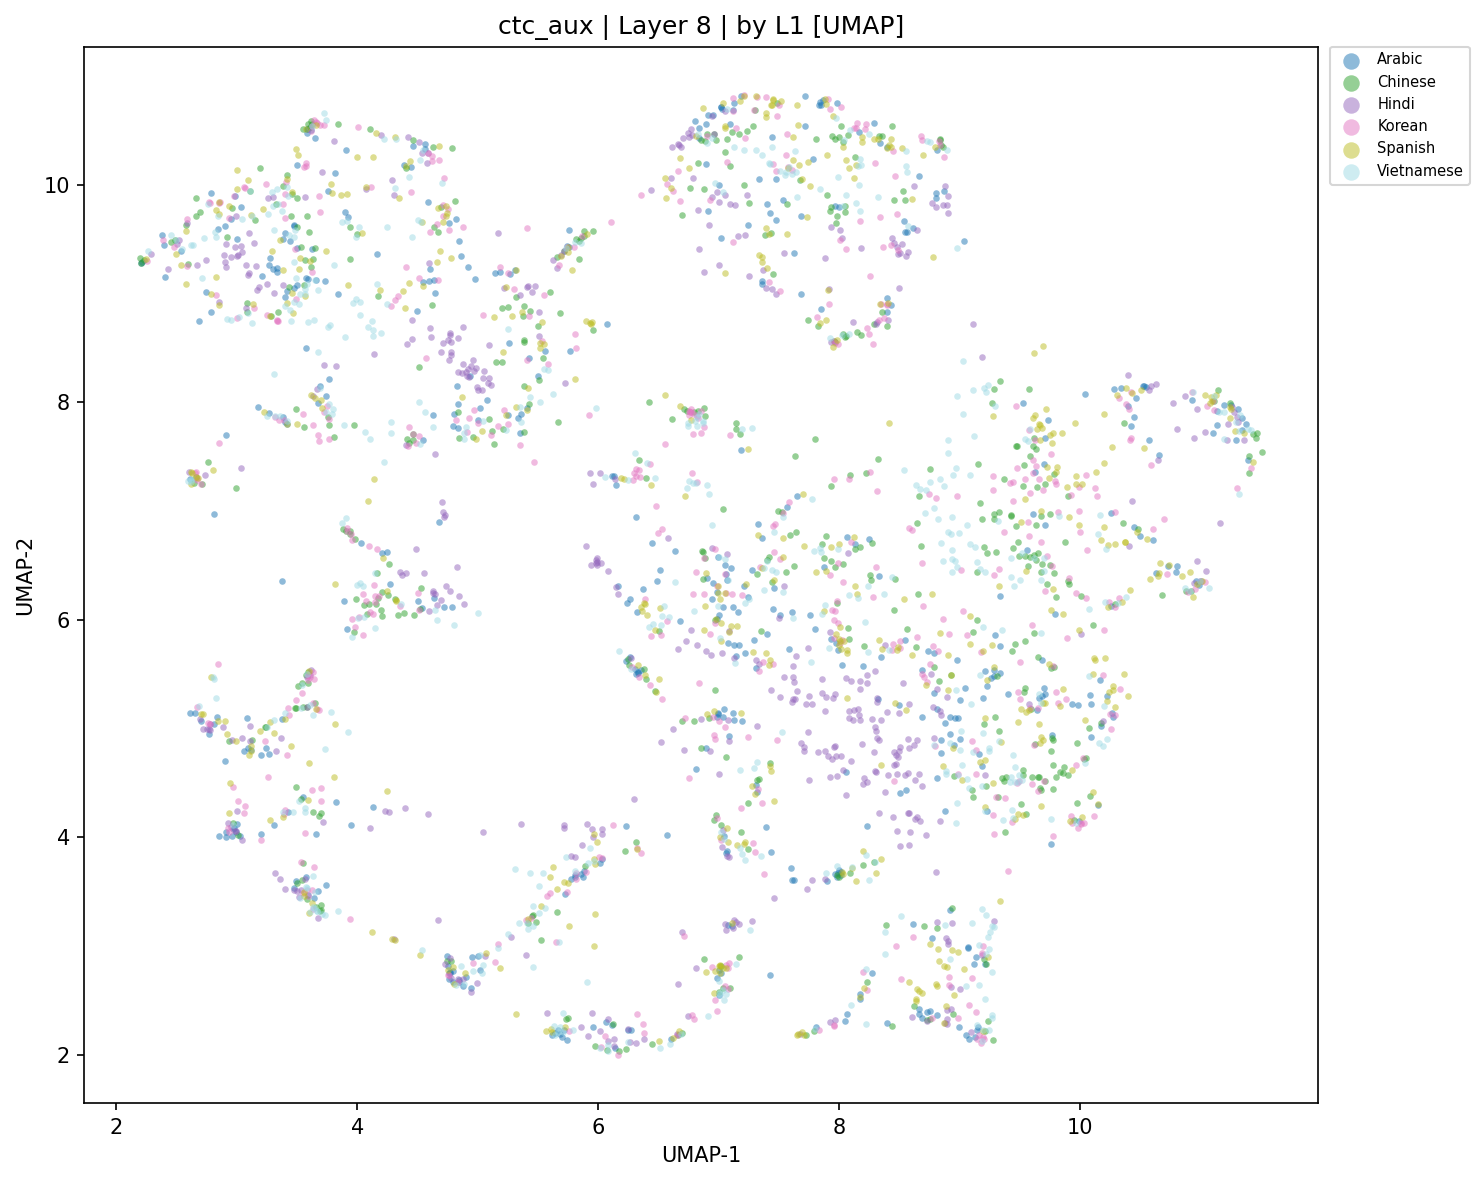

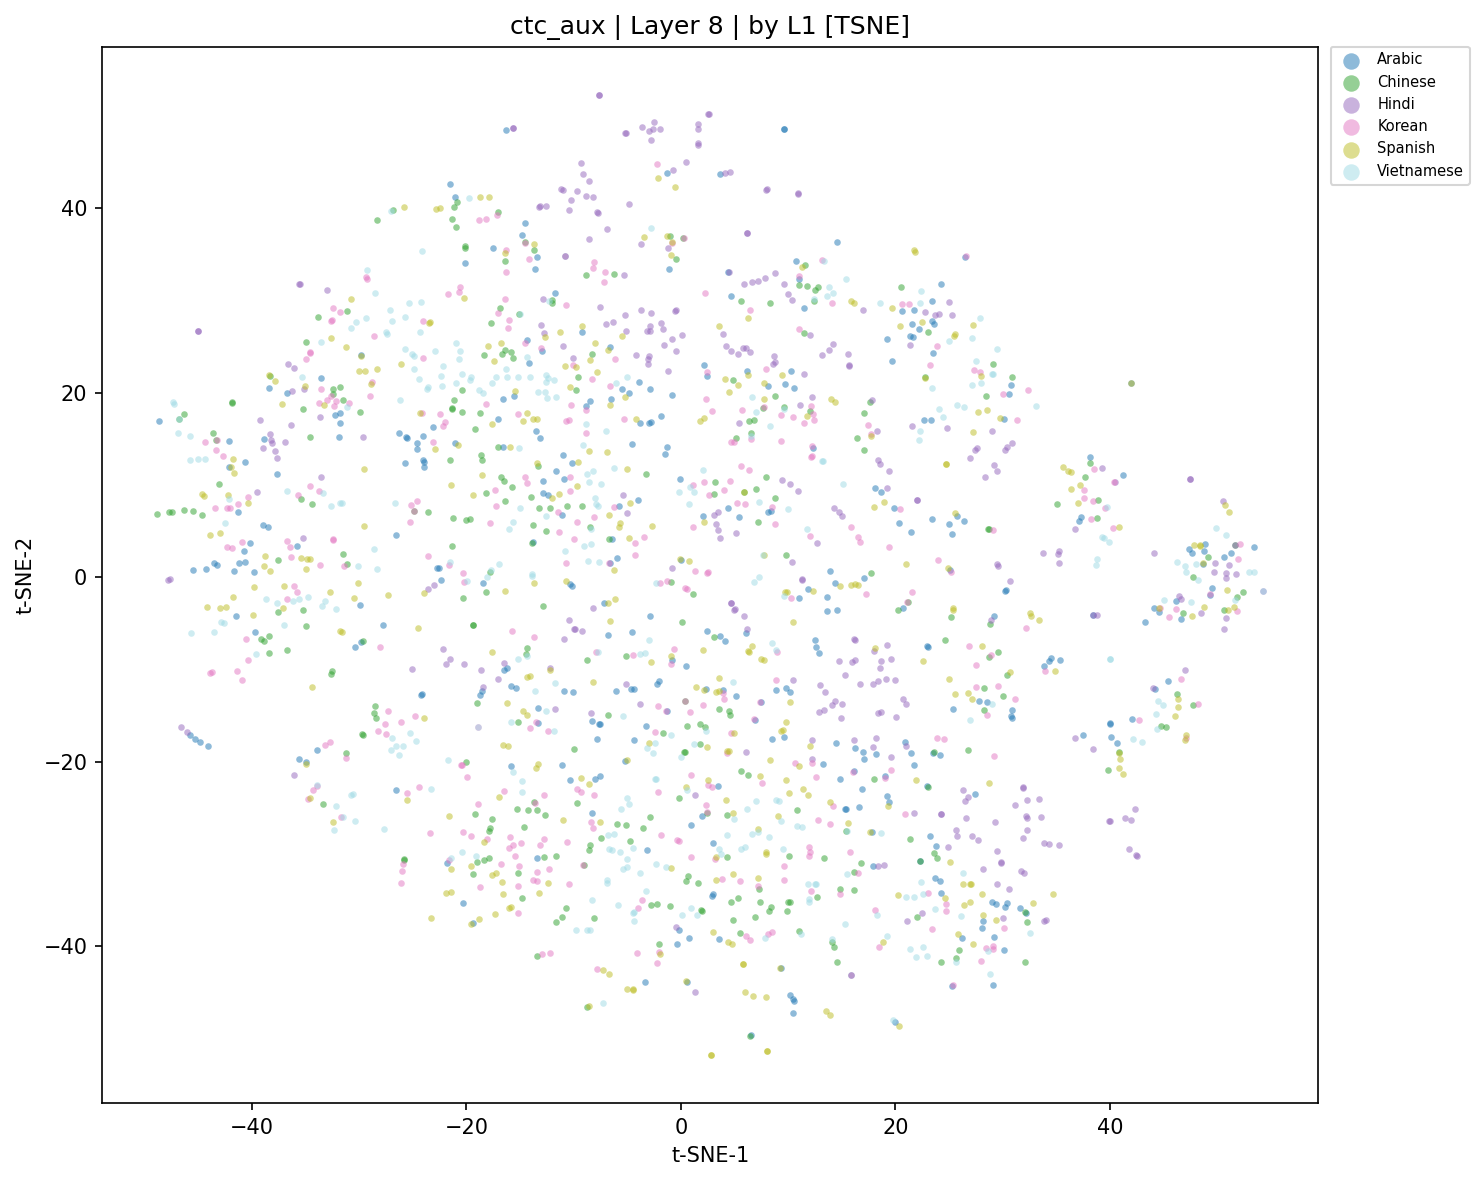

In [5]:
# ── Side-by-side UMAP vs t-SNE comparison — edit to your most interesting layer
COMPARE_LAYER      = 8          # whichever layer looks most informative
COMPARE_PLOT_TYPE  = "l1"       # "l1" | "phoneme" | "focus_phones" | "focus_phones_l1"
COMPARE_MODEL      = "ctc_aux"

display(HTML(f"<h3>UMAP vs t-SNE — {COMPARE_MODEL} | Layer {COMPARE_LAYER} | {COMPARE_PLOT_TYPE}</h3>"))
for method in ("umap", "tsne"):
    path = PLOTS_DIR / COMPARE_MODEL / f"{method}_{COMPARE_MODEL}_layer{COMPARE_LAYER}_{COMPARE_PLOT_TYPE}.png"
    display(HTML(f"<b>{method.upper()}</b>"))
    if path.exists():
        from IPython.display import Image as IPImage
        display(IPImage(str(path), width=700))
    else:
        display(HTML(f'<span style="color:red">Missing: {path.name}</span>'))

---
# Section 2 — Metric Tables

In [6]:
for label_type in LABEL_TYPES:
    display(HTML(f"<h3>Label: <code>{label_type}</code></h3>"))
    sub = df[df["label_type"] == label_type].copy()
    for metric, (title, note) in METRICS.items():
        pivot = sub.pivot(index="layer", columns="model", values=metric)
        pivot.columns = [MODEL_STYLES.get(c, {}).get("label", c) for c in pivot.columns]
        pivot.index.name = "Layer"
        cmap = "RdYlGn" if "↑" in title else "RdYlGn_r"
        display(HTML(f'<b>{title}</b> <span style="color:#888;font-size:12px">({note})</span>'))
        display(pivot.style.format("{:.4f}").background_gradient(cmap=cmap, axis=None))
    display(HTML("<hr/>"))

,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,-0.1170,-0.1381,-0.1278
1,-0.0687,-0.0500,-0.0627
2,-0.0317,-0.0442,-0.0449
3,-0.0413,-0.0248,-0.0405
4,-0.0088,-0.0350,-0.0561
5,0.0052,0.0029,-0.0042
6,0.0123,0.0109,0.0032
7,0.0126,0.0002,0.0060
8,0.0097,0.0071,0.0104


,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,9.4968,9.4968,9.4968
1,7.5592,7.6198,7.7724
2,6.9283,7.0168,7.0931
3,6.5091,6.5689,6.6680
4,6.2729,6.3881,6.3474
5,5.6920,5.7717,5.9720
6,5.5460,5.6036,5.8477
7,5.5446,5.5967,5.7710
8,5.2884,5.2682,5.3157


,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,10.3130,10.3130,10.3130
1,14.8132,14.6430,13.8881
2,17.0249,16.5302,16.6468
3,17.4494,17.9017,17.4931
4,17.5288,17.6668,19.7751
5,19.6432,20.5455,19.4783
6,18.1316,19.3831,18.2654
7,18.2016,19.4231,18.7304
8,18.3170,19.8748,19.9510


,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,2.1707,2.1707,2.1707
1,1.8554,1.8689,1.9175
2,1.7515,1.7741,1.7754
3,1.7228,1.7062,1.7263
4,1.7017,1.6964,1.6273
5,1.6057,1.5755,1.6351
6,1.6582,1.6101,1.6761
7,1.6570,1.6121,1.6559
8,1.6358,1.5754,1.5801


,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,-0.0241,-0.0217,-0.0221
1,-0.0073,-0.0061,-0.0088
2,-0.0032,-0.0028,-0.0064
3,-0.0021,-0.0026,-0.0027
4,-0.0005,-0.0014,-0.0059
5,0.0002,-0.0005,-0.0037
6,0.0048,0.0067,0.0062
7,0.0159,0.0247,0.0196
8,0.0203,0.0384,0.0307


...

,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,6.5193,6.5193,6.5193
1,5.9242,5.7975,5.8798
2,5.6257,5.3996,5.6105
3,5.9011,5.7521,6.0420
4,6.2734,6.0781,6.6952
5,6.1304,6.0301,5.9159
6,5.4208,5.0389,5.1993
7,3.8190,3.2273,3.4187
8,3.2715,2.6626,2.8770


,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,-0.0402,-0.0418,-0.0457
1,-0.0069,-0.0138,-0.0130
2,-0.0015,-0.0009,-0.0036
3,-0.0020,-0.0027,-0.0127
4,-0.0031,-0.0032,-0.0232
5,-0.0038,-0.0068,-0.0158
6,-0.0040,-0.0029,-0.0073
7,0.0006,-0.0009,-0.0045
8,-0.0015,-0.0052,-0.0059


,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,9.6858,9.6858,9.6858
1,8.6896,8.6142,8.7780
2,8.2880,8.1503,8.3793
3,8.7989,8.7220,9.2431
4,9.5362,9.4054,10.4355
5,9.8868,9.9508,10.4766
6,10.6343,10.5888,10.9996
7,9.8693,9.9168,10.3251
8,10.8996,11.2481,11.4417


,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,9.3596,9.3596,9.3596
1,13.2071,13.4833,13.3989
2,12.3751,13.9614,13.1686
3,9.7985,10.7464,9.5124
4,8.2135,9.0809,7.0804
5,7.4470,7.9470,7.1740
6,7.2452,7.9961,7.3241
7,11.1815,13.7505,12.5541
8,12.5913,16.5985,14.8171


,Baseline (frozen),Naive LoRA FT,CTC Aux
Layer,,,
0,3.3338,3.3338,3.3338
1,2.8274,2.7996,2.8095
2,2.9069,2.7483,2.8281
3,3.2508,3.1126,3.3064
4,3.5513,3.3874,3.8361
5,3.7236,3.6157,3.8177
6,3.8081,3.6317,3.8051
7,3.0822,2.7937,2.9434
8,2.9233,2.5635,2.7265


---
# Section 3 — Layer Progression Charts

In [7]:
# ── 3a. Per-label metric progression ─────────────────────────────────────────
for label_type in LABEL_TYPES:
    sub = df[df["label_type"] == label_type]
    fig = make_subplots(rows=2, cols=2,
                        subplot_titles=[t for t, _ in METRICS.values()])
    positions = [(1,1),(1,2),(2,1),(2,2)]
    for (metric, (title, _)), (r, c) in zip(METRICS.items(), positions):
        for key in MODELS:
            msub = sub[sub["model"] == key].sort_values("layer")
            s    = MODEL_STYLES.get(key, {})
            fig.add_trace(go.Scatter(
                x=msub["layer"], y=msub[metric],
                name=s.get("label", key), legendgroup=key,
                showlegend=(r == 1 and c == 1),
                line=dict(color=s.get("color"), dash=s.get("dash"), width=2),
                mode="lines+markers",
            ), row=r, col=c)
        fig.update_xaxes(title_text="Layer", row=r, col=c)
        fig.update_yaxes(title_text=metric[:14], row=r, col=c)
    fig.update_layout(
        title=f"Clustering Metrics by Layer — {label_type}",
        height=600,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    )
    fig.show()

In [8]:
# ── 3b. Silhouette cross-label comparison (all three on same axes per model) ──
LABEL_COLORS = {"phoneme": "#00CC96", "l1": "#AB63FA", "speaker": "#FFA15A"}
LABEL_DASH   = {"phoneme": "solid",   "l1": "dot",     "speaker": "dash"}

fig = make_subplots(rows=1, cols=len(MODELS),
                    subplot_titles=[MODEL_STYLES.get(k, {}).get("label", k) for k in MODELS],
                    shared_yaxes=True)
for ci, key in enumerate(MODELS):
    for lt in LABEL_TYPES:
        sub = df[(df["model"] == key) & (df["label_type"] == lt)].sort_values("layer")
        fig.add_trace(go.Scatter(
            x=sub["layer"], y=sub["silhouette"],
            name=lt, legendgroup=lt, showlegend=(ci == 0),
            mode="lines+markers",
            line=dict(color=LABEL_COLORS[lt], dash=LABEL_DASH[lt], width=2),
        ), row=1, col=ci + 1)
fig.add_hline(y=0, line_dash="dot", line_color="gray", line_width=1)
fig.update_xaxes(title_text="Layer")
fig.update_yaxes(title_text="Silhouette Score", col=1)
fig.update_layout(
    title="Silhouette Score by Layer: Phoneme vs L1 vs Speaker",
    height=420,
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5),
)
fig.show()

---
# Section 4 — Delta: Fine-tuned vs Baseline

In [9]:
# For each non-baseline model, show LoRA-improvement delta tables + bar charts
for ft_key in [k for k in MODELS if k != "baseline"]:
    if "baseline" not in raw:
        continue
    ft_label = MODEL_STYLES.get(ft_key, {}).get("label", ft_key)
    display(HTML(f"<h3>{ft_label} − Baseline Delta (positive = improvement)</h3>"))

    for label_type in LABEL_TYPES:
        base = df[(df["model"] == "baseline") & (df["label_type"] == label_type)].set_index("layer")
        ft   = df[(df["model"] == ft_key)     & (df["label_type"] == label_type)].set_index("layer")
        if ft.empty:
            continue
        delta = pd.DataFrame(index=LAYERS)
        for metric, (title, note) in METRICS.items():
            sign = -1 if "↓" in note else 1
            delta[title] = sign * (ft[metric] - base[metric])
        delta.index.name = "Layer"
        display(HTML(f"<b>{label_type}</b>"))
        display(delta.style.format("{:+.4f}")
                .background_gradient(cmap="RdYlGn", axis=None))

    # Bar chart: silhouette delta by label_type
    fig = go.Figure()
    for lt in LABEL_TYPES:
        base = df[(df["model"] == "baseline") & (df["label_type"] == lt)].sort_values("layer")
        ft   = df[(df["model"] == ft_key)     & (df["label_type"] == lt)].sort_values("layer")
        if ft.empty:
            continue
        delta = ft["silhouette"].values - base["silhouette"].values
        fig.add_trace(go.Bar(
            x=LAYERS, y=delta.tolist(), name=lt,
            marker_color=LABEL_COLORS[lt],
        ))
    fig.add_hline(y=0, line_color="black", line_width=0.8)
    fig.update_layout(
        title=f"Silhouette Δ by Layer — {ft_label} vs Baseline",
        barmode="group", height=380,
        legend=dict(orientation="h", y=1.05, xanchor="center", x=0.5),
    )
    fig.update_xaxes(title_text="Layer")
    fig.update_yaxes(title_text="Δ Silhouette")
    fig.show()

,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Within/Between Ratio ↓
Layer,,,,
0,-0.0211,+0.0000,+0.0000,+0.0000
1,+0.0186,+0.0606,-0.1702,+0.0135
2,-0.0125,+0.0884,-0.4947,+0.0226
3,+0.0165,+0.0598,+0.4523,-0.0166
4,-0.0261,+0.1152,+0.1380,-0.0053
5,-0.0022,+0.0797,+0.9023,-0.0303
6,-0.0014,+0.0576,+1.2515,-0.0481
7,-0.0124,+0.0521,+1.2215,-0.0449
8,-0.0026,-0.0201,+1.5579,-0.0604


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Within/Between Ratio ↓
Layer,,,,
0,+0.0025,+0.0000,+0.0000,+0.0000
1,+0.0011,-0.0478,+0.6017,-0.1267
2,+0.0004,-0.3357,+1.2098,-0.2261
3,-0.0005,-0.4546,+0.6357,-0.1490
4,-0.0008,-0.4678,+0.7014,-0.1952
5,-0.0007,-0.2369,+0.4293,-0.1002
6,+0.0018,-0.6251,+2.3175,-0.3819
7,+0.0088,-1.3014,+11.6880,-0.5917
8,+0.0181,-1.8198,+19.8867,-0.6089


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Within/Between Ratio ↓
Layer,,,,
0,-0.0017,+0.0000,+0.0000,+0.0000
1,-0.0069,-0.0755,+0.2762,-0.0278
2,+0.0006,-0.1377,+1.5864,-0.1586
3,-0.0007,-0.0768,+0.9479,-0.1383
4,-0.0001,-0.1308,+0.8674,-0.1639
5,-0.0030,+0.0640,+0.5000,-0.1079
6,+0.0011,-0.0454,+0.7508,-0.1764
7,-0.0015,+0.0475,+2.5690,-0.2885
8,-0.0038,+0.3485,+4.0071,-0.3598


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Within/Between Ratio ↓
Layer,,,,
0,-0.0108,+0.0000,+0.0000,+0.0000
1,+0.0059,+0.2132,-0.9251,+0.0620
2,-0.0132,+0.1648,-0.3780,+0.0240
3,+0.0008,+0.1589,+0.0437,+0.0035
4,-0.0473,+0.0745,+2.2463,-0.0744
5,-0.0093,+0.2800,-0.1648,+0.0294
6,-0.0091,+0.3017,+0.1338,+0.0179
7,-0.0066,+0.2264,+0.5288,-0.0011
8,+0.0008,+0.0273,+1.6340,-0.0557


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Within/Between Ratio ↓
Layer,,,,
0,+0.0020,+0.0000,+0.0000,+0.0000
1,-0.0016,+0.2420,+0.2693,-0.0444
2,-0.0032,+0.1948,+0.1400,-0.0152
3,-0.0006,+0.4534,-0.5053,+0.1409
4,-0.0054,+1.1604,-1.2579,+0.4218
5,-0.0039,-0.0005,+1.2170,-0.2145
6,+0.0014,+0.0383,+1.5314,-0.2215
7,+0.0036,-0.3330,+8.1824,-0.4003
8,+0.0104,-0.7492,+12.5163,-0.3945


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Within/Between Ratio ↓
Layer,,,,
0,-0.0055,+0.0000,+0.0000,+0.0000
1,-0.0061,+0.0883,+0.1919,-0.0179
2,-0.0022,+0.0913,+0.7936,-0.0787
3,-0.0107,+0.4442,-0.2861,+0.0555
4,-0.0201,+0.8993,-1.1331,+0.2848
5,-0.0120,+0.5898,-0.2730,+0.0942
6,-0.0034,+0.3653,+0.0788,-0.0030
7,-0.0052,+0.4558,+1.3726,-0.1389
8,-0.0044,+0.5421,+2.2258,-0.1968


---
# Section 5 — Deeper Diagnostics

In [10]:
# ── 5a. Accent-Phoneme Entanglement Index ─────────────────────────────────────
display(HTML("<h4>Accent-Phoneme Entanglement Index (L1 sil / |phoneme sil|)</h4>"))
display(HTML('<p style="color:#888">Higher = accent more structured than phoneme = more entangled</p>'))

fig = go.Figure()
for key in MODELS:
    ph = df[(df["model"] == key) & (df["label_type"] == "phoneme")].sort_values("layer")
    l1 = df[(df["model"] == key) & (df["label_type"] == "l1")].sort_values("layer")
    ratio = l1["silhouette"].values / (np.abs(ph["silhouette"].values) + 1e-8)
    s = MODEL_STYLES.get(key, {})
    fig.add_trace(go.Scatter(
        x=LAYERS, y=ratio.tolist(), name=s.get("label", key),
        mode="lines+markers",
        line=dict(color=s.get("color"), dash=s.get("dash"), width=2),
    ))
fig.update_layout(title="Accent-Phoneme Entanglement Index", height=380,
                  legend=dict(orientation="h", y=1.05, xanchor="center", x=0.5))
fig.update_xaxes(title_text="Layer")
fig.update_yaxes(title_text="L1 sil / |phoneme sil|")
fig.show()

In [11]:
# ── 5b. L1 − Speaker silhouette: group-level vs speaker-level accent ──────────
display(HTML("<h4>L1 − Speaker Silhouette Delta</h4>"))
display(HTML('<p style="color:#888">'
             "Positive = accent encoded as group-level structure beyond speaker identity. "
             "Near zero = accent is a proxy for speaker ID.</p>"))

fig = go.Figure()
for key in MODELS:
    l1  = df[(df["model"] == key) & (df["label_type"] == "l1")].sort_values("layer")
    spk = df[(df["model"] == key) & (df["label_type"] == "speaker")].sort_values("layer")
    delta = l1["silhouette"].values - spk["silhouette"].values
    s = MODEL_STYLES.get(key, {})
    fig.add_trace(go.Scatter(
        x=LAYERS, y=delta.tolist(), name=s.get("label", key),
        mode="lines+markers",
        line=dict(color=s.get("color"), dash=s.get("dash"), width=2),
    ))
fig.add_hline(y=0, line_dash="dot", line_color="gray")
fig.update_layout(title="L1 − Speaker Silhouette Delta by Layer", height=380,
                  legend=dict(orientation="h", y=1.05, xanchor="center", x=0.5))
fig.update_xaxes(title_text="Layer")
fig.update_yaxes(title_text="Δ Silhouette (L1 − Speaker)")
fig.show()

In [12]:
# ── 5c. Best-layer radar chart ────────────────────────────────────────────────
display(HTML("<h4>Best-Layer Metric Summary — Radar</h4>"))
radar_metrics = list(METRICS.keys())
radar_labels  = [t for t, _ in METRICS.values()]

fig = go.Figure()
for key in MODELS:
    for lt in ["phoneme", "l1"]:
        sub  = df[(df["model"] == key) & (df["label_type"] == lt)]
        vals = []
        for metric, (_, note) in METRICS.items():
            vals.append(float(sub[metric].min() if "↓" in note else sub[metric].max()))
        fig.add_trace(go.Scatterpolar(
            r=vals + [vals[0]], theta=radar_labels + [radar_labels[0]],
            name=f"{MODEL_STYLES.get(key,{}).get('label',key)}/{lt}",
            fill="toself", opacity=0.25,
        ))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title="Best-Layer Metric Summary (raw values — axes not comparable across metrics)",
    height=500,
    legend=dict(orientation="h", y=-0.2, xanchor="center", x=0.5),
)
fig.show()

---
# Section 6 — Numerical Summary

In [13]:
pd.set_option("display.float_format", "{:.4f}".format)
out_path = Path("results/clustering_summary.csv")
df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
display(df.sort_values(["model", "label_type", "layer"]))

Saved: results/clustering_summary.csv


,model,layer,label_type,silhouette,davies_bouldin,calinski_harabasz,wb_ratio,within_mean,between_mean,n_samples,n_classes
1,baseline,0,l1,-0.0241,17.3488,10.2628,6.5193,27.2050,4.1730,5000,6
4,baseline,1,l1,-0.0073,14.7497,12.0953,5.9242,27.2451,4.5990,5000,6
7,baseline,2,l1,-0.0032,13.6090,13.3358,5.6257,27.2354,4.8412,5000,6
10,baseline,3,l1,-0.0021,14.0486,12.0919,5.9011,27.2602,4.6195,5000,6
13,baseline,4,l1,-0.0005,15.2534,10.7428,6.2734,27.2750,4.3477,5000,6
...,...,...,...,...,...,...,...,...,...,...,...
104,ctc_aux,8,speaker,-0.0059,11.4417,14.8171,2.7265,26.6114,9.7603,5000,24
107,ctc_aux,9,speaker,-0.0082,13.6079,8.1187,3.6539,26.9338,7.3713,5000,24
110,ctc_aux,10,speaker,-0.0101,15.5846,4.4983,4.8286,26.9574,5.5828,5000,24
113,ctc_aux,11,speaker,-0.0123,16.2845,3.4185,5.5044,26.9456,4.8953,5000,24
